# Task 1 – Data Loading, Merging & Deep Exploration

Step 1: Install Libraries

In [684]:
!pip install pandas numpy matplotlib seaborn plotly

Step 2: Import Libraries

In [685]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Step 3: Load Dataset

In [686]:
df = pd.read_csv(r"C:\Users\sujit\Downloads\train.csv.zip")

In [687]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [688]:
df.shape

(9800, 18)

In [689]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Step 4: Basic Information

In [690]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [691]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Step 5: Convert Date Columns

In [692]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)


In [693]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

Step 6: Feature Engineering

In [694]:
df['Year'] = pd.to_datetime(df['Order Date'], dayfirst=True).dt.year


In [695]:
df['Month'] = df['Order Date'].dt.month

In [696]:
df['Quarter'] = df['Order Date'].dt.quarter

In [697]:
df['Week'] = df['Order Date'].dt.isocalendar().week

In [698]:
df['Day'] = df['Order Date'].dt.day

In [699]:
df['Day Name'] = df['Order Date'].dt.day_name()

Season

In [700]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

check

In [701]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Quarter,Week,Day,Day Name,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,45,8,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,45,8,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,24,12,Monday,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,41,11,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,41,11,Tuesday,Autumn


Step 7: Missing Values

In [702]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Quarter           0
Week              0
Day               0
Day Name          0
Season            0
dtype: int64

In [703]:
df = df.dropna()

Step 8: Duplicate Values

In [704]:
df.duplicated().sum()

0

In [705]:
df = df.drop_duplicates()

Step 9: Weekly Sales

In [706]:
weekly_sales = df.groupby(pd.Grouper(key='Order Date',freq='W'))['Sales'].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [707]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date',freq='M'))['Sales'].sum().reset_index()

monthly_sales.head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_18500\3871685381.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Step 11: Category Wise Sales

In [708]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

Bar Chart

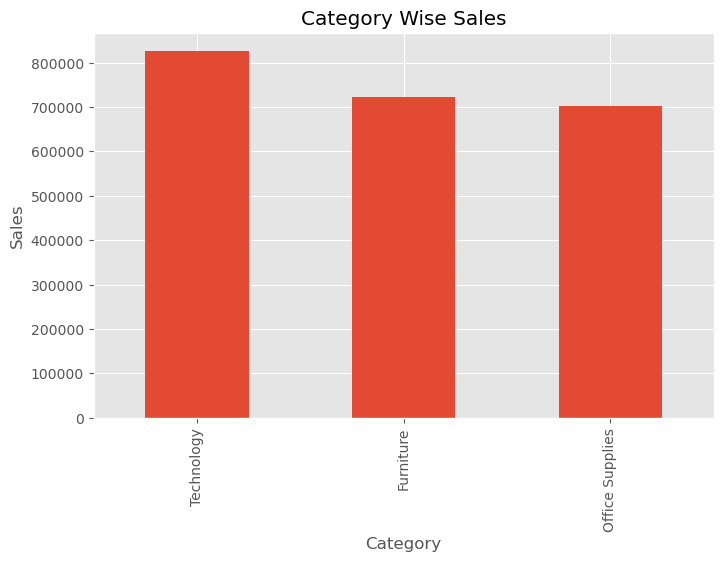

In [709]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Category Wise Sales")

plt.ylabel("Sales")

plt.show()

Step 12: Region Wise Sales

In [710]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

Chart

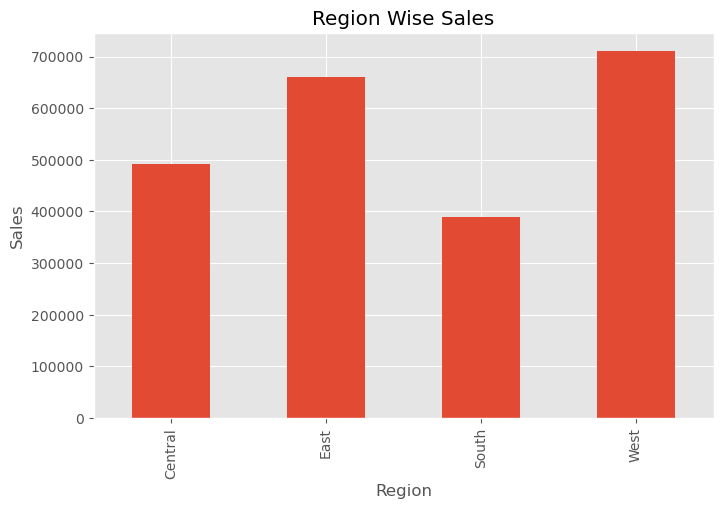

In [711]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Region Wise Sales")

plt.ylabel("Sales")

plt.show()

Step 13: Monthly Sales Trend

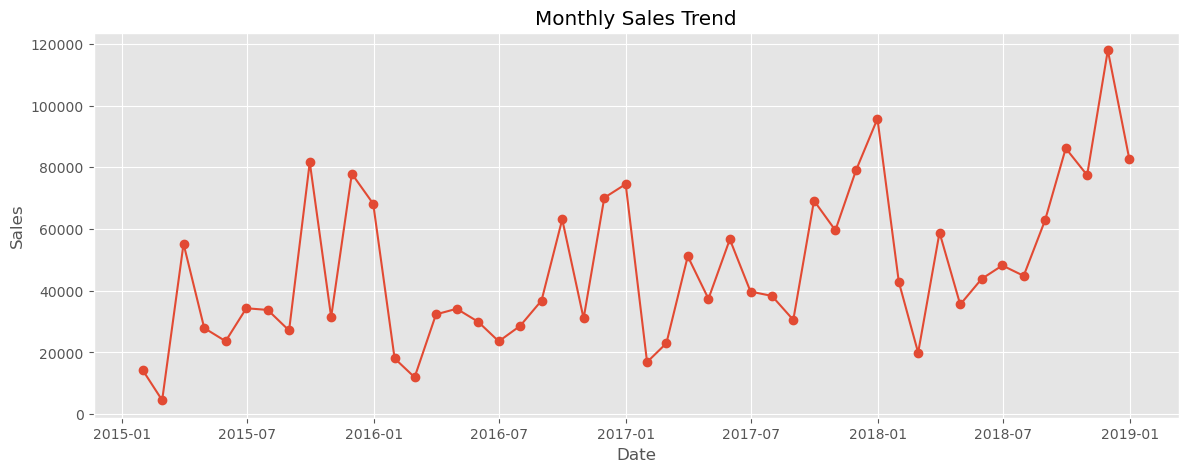

In [712]:
plt.figure(figsize=(14,5))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"],
         marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

Step 14: Average Shipping Time

In [713]:
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

df["Shipping Days"].mean()

3.961180917356216

Region Wise

In [714]:
shipping=df.groupby("Region")["Shipping Days"].mean()

shipping

Region
Central    4.065876
East       3.910238
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

Bar Chart

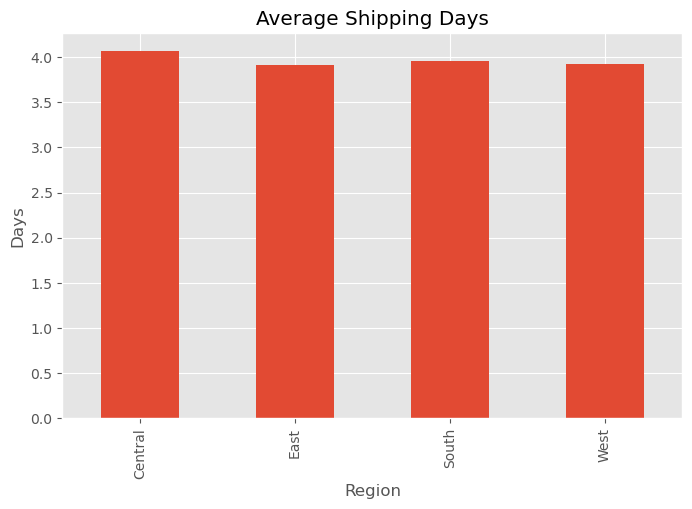

In [715]:
shipping.plot(kind="bar",figsize=(8,5))

plt.title("Average Shipping Days")

plt.ylabel("Days")

plt.show()

Step 15: Which Category Generates Highest Revenue?

In [716]:
category_sales

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

Step 16: Which Region Shows Most Consistent Growth?

In [717]:
region_monthly=df.groupby(
['Region',
pd.Grouper(key='Order Date',freq='M')]
)['Sales'].sum().reset_index()

region_monthly.head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_18500\550696898.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,Region,Order Date,Sales
0,Central,2015-01-31,1533.966
1,Central,2015-02-28,1233.174
2,Central,2015-03-31,5827.602
3,Central,2015-04-30,3712.340
4,Central,2015-05-31,4044.522


Plot

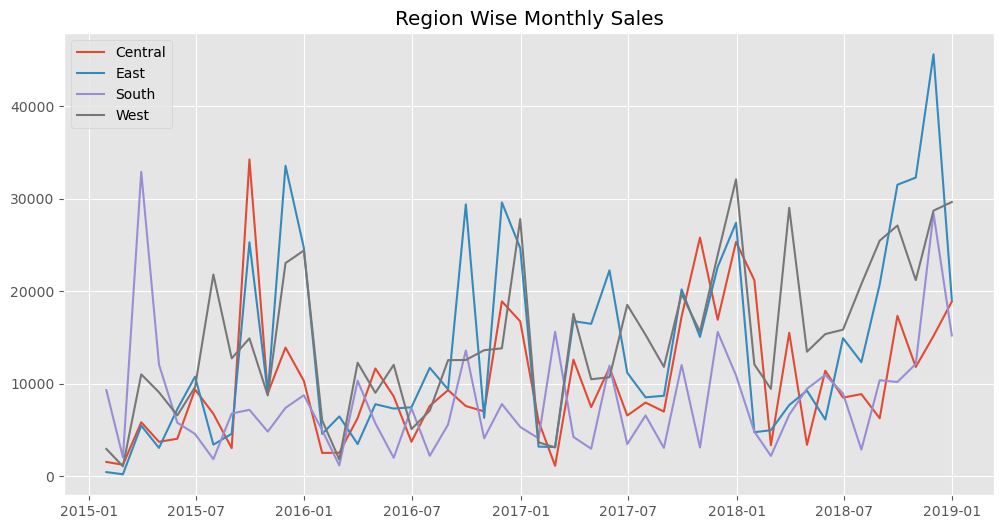

In [718]:
plt.figure(figsize=(12,6))

for region in region_monthly['Region'].unique():

    temp=region_monthly[
        region_monthly['Region']==region
    ]

    plt.plot(temp['Order Date'],
             temp['Sales'],
             label=region)

plt.legend()

plt.title("Region Wise Monthly Sales")

plt.show()

Step 17: Seasonality

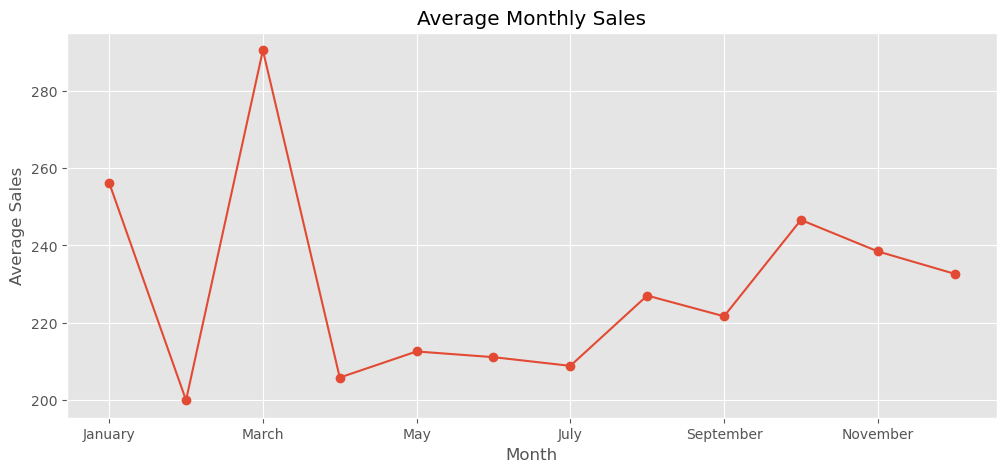

In [719]:
# Step 1: Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Step 2: Create Month Name column
df['Month Name'] = df['Order Date'].dt.month_name()

# Step 3: Group by Month Name and calculate average sales
seasonality = df.groupby("Month Name")["Sales"].mean()

# Step 4: Reindex to calendar order
seasonality = seasonality.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

# Step 5: Plot the result
seasonality.plot(figsize=(12,5), marker="o")
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


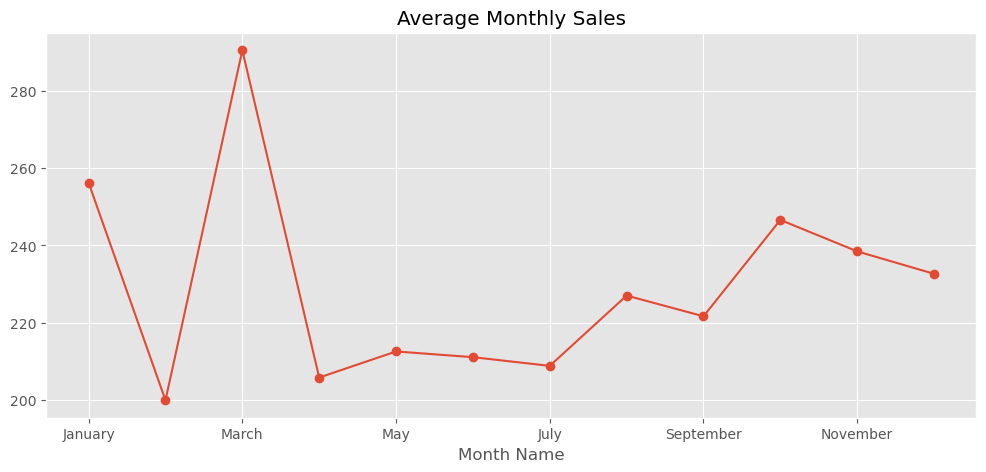

In [720]:
seasonality=seasonality.reindex([
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
])

seasonality.plot(figsize=(12,5),marker="o")

plt.title("Average Monthly Sales")

plt.show()

Task 1 Conclusion

1. The dataset contains historical Superstore sales transactions.

2. Date columns were converted into datetime format.

3. New features such as Year, Month, Quarter, Week, Day, Season, and Shipping Days were created.

4. Missing values and duplicate records were checked and handled.

5. Weekly and monthly sales were aggregated for future forecasting.

6. Category-wise and region-wise sales were analyzed.

7. Monthly sales trend indicates overall business growth and seasonal fluctuations.

8. Average shipping time varies slightly across regions.

9. Seasonality is visible in some months with higher average sales.

10. The cleaned dataset is now ready for Time Series Analysis in Task 2.

# Task 2 – Time Series Analysis & Decomposition

Step 1: Install Required Library

In [721]:
!pip install statsmodels

Step 2: Import Libraries

In [722]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

Step 3: Create Monthly Time Series

In [723]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

Step 4: Plot Monthly Sales Trend (4 Years)

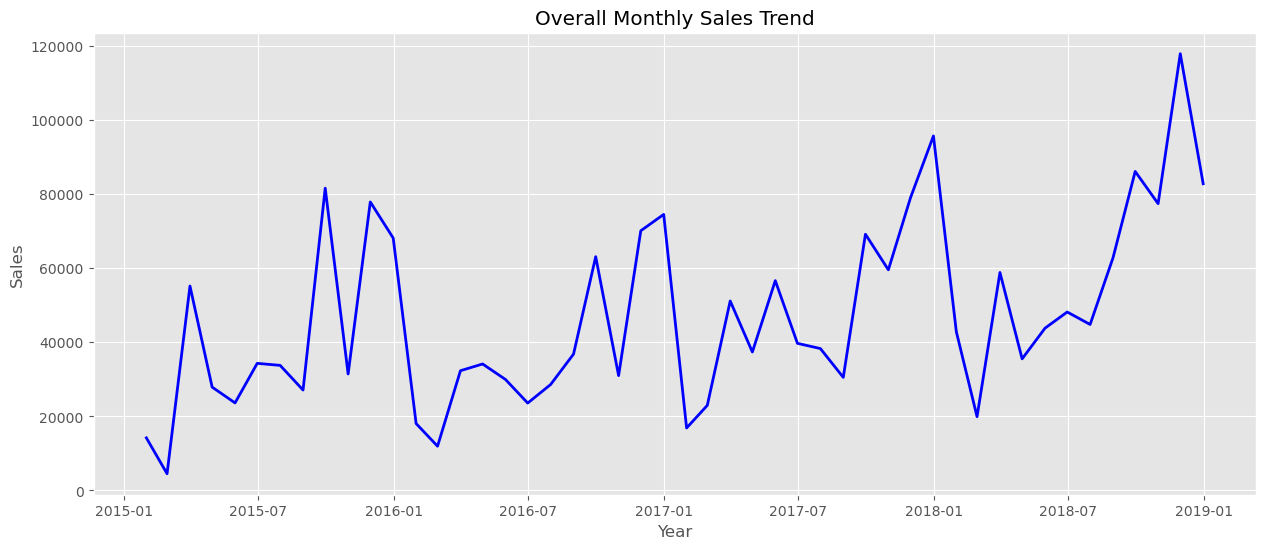

In [724]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales,
         color='blue',
         linewidth=2)

plt.title("Overall Monthly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Observation:

• Sales generally increase over time.
• A few months show sharp spikes.
• Sales fluctuate seasonally.
• Overall trend is upward.

Step 5: Time Series Decomposition

In [725]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

Step 6: Plot Decomposition

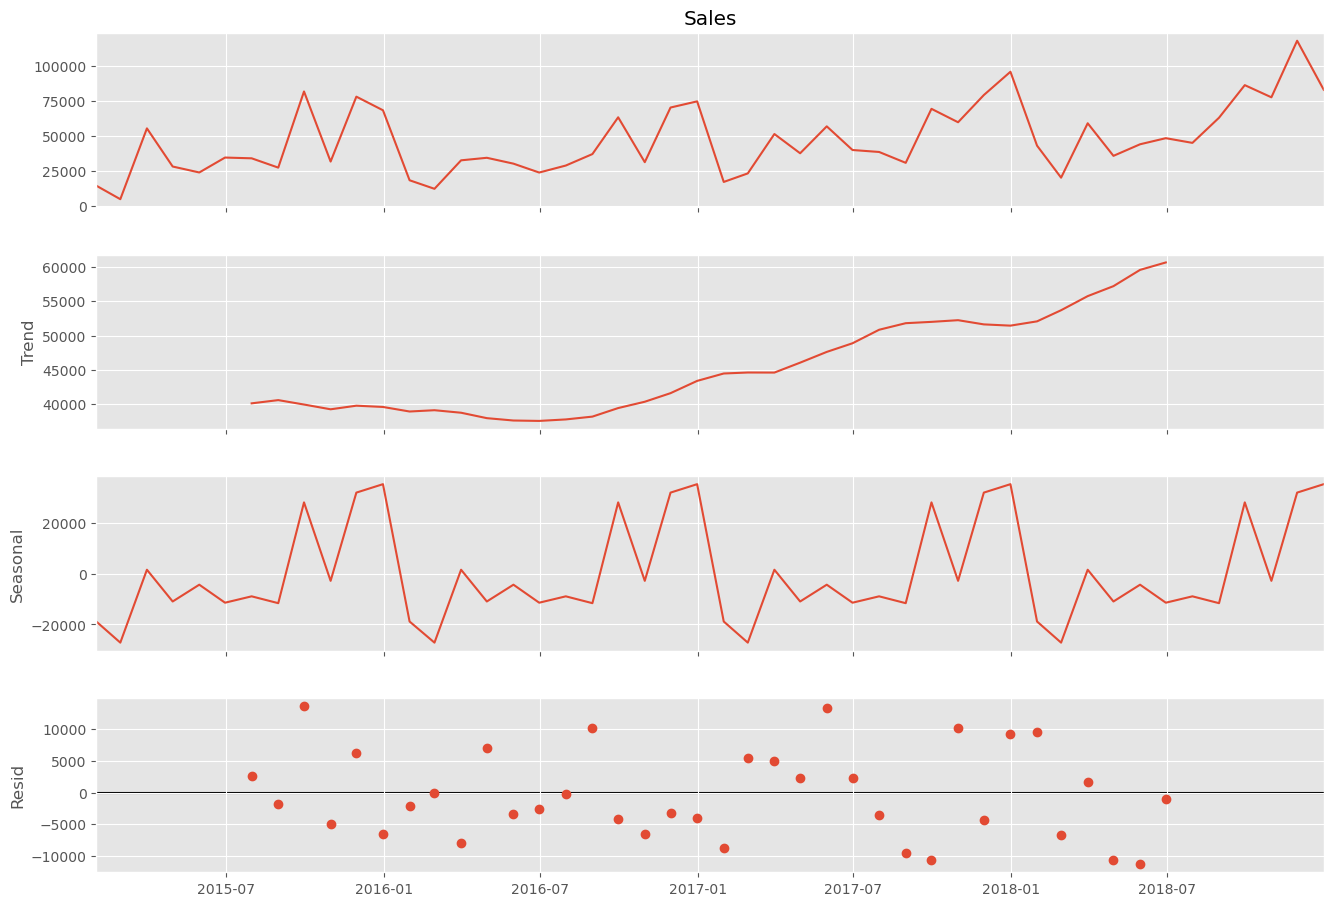

In [726]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

Step 7: Individual Components

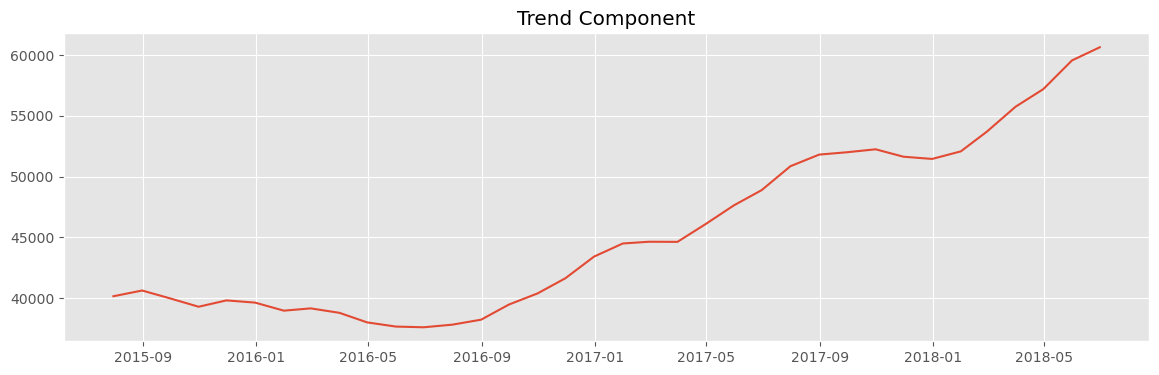

In [727]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.trend)

plt.title("Trend Component")

plt.show()

Seasonal

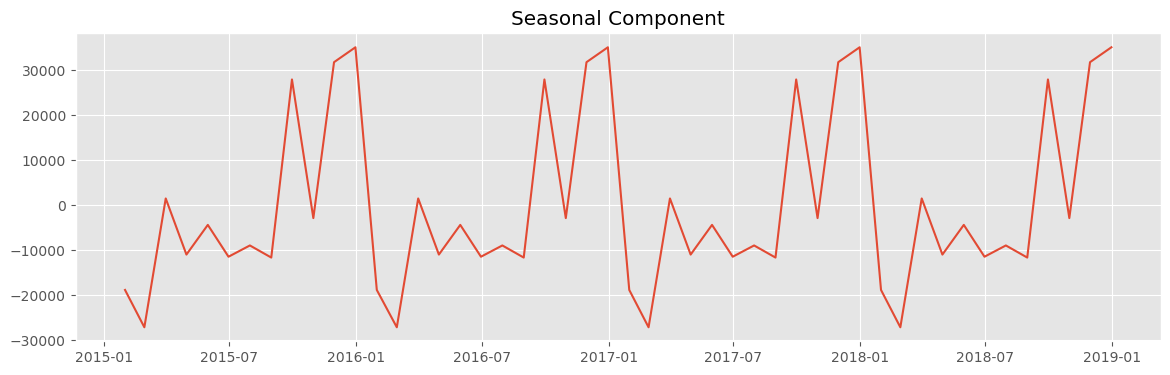

In [728]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.seasonal)

plt.title("Seasonal Component")

plt.show()

Residual

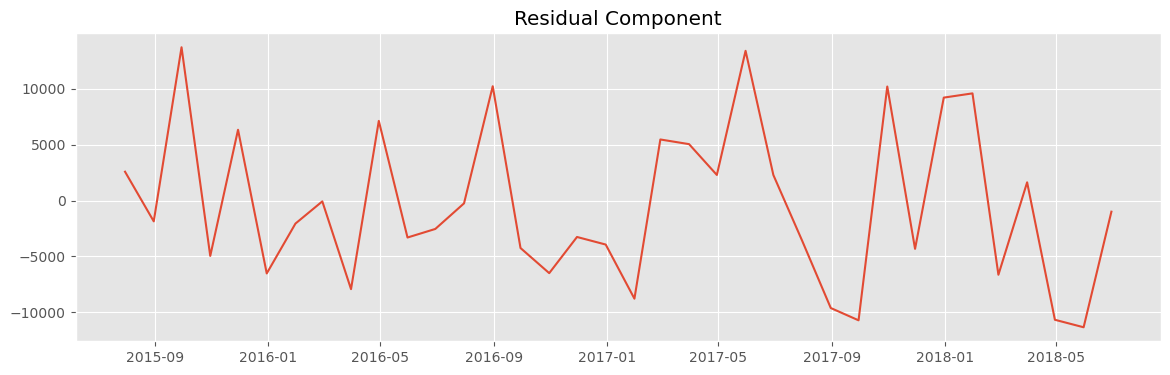

In [729]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.resid)

plt.title("Residual Component")

plt.show()

Step 8: ADF Test (Stationarity Test)

In [730]:
result = adfuller(monthly_sales.dropna())

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values:")

for key,value in result[4].items():

    print(key,":",value)

ADF Statistic : -4.424951605714015
p-value : 0.0002680629728011447
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


Step 9: Interpret ADF Result

In [731]:
if result[1] < 0.05:

    print("Time Series is Stationary")

else:

    print("Time Series is NOT Stationary")

Time Series is Stationary


Step 10: Apply Differencing (if Non-Stationary)


In [732]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

Step 11: Plot Differenced Series

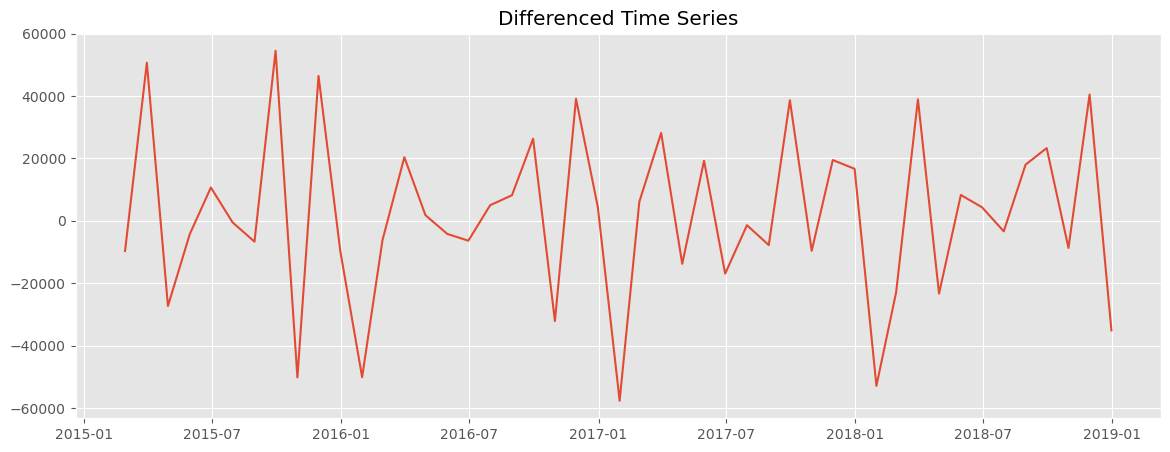

In [733]:
plt.figure(figsize=(14,5))

plt.plot(monthly_sales_diff)

plt.title("Differenced Time Series")

plt.grid(True)

plt.show()

Step 12: Re-run ADF Test

In [734]:
result2 = adfuller(monthly_sales_diff)

print("ADF Statistic :",result2[0])

print("p-value :",result2[1])

ADF Statistic : -8.523376913103988
p-value : 1.085453626576139e-13


Step 13: Final Interpretation

In [735]:
if result2[1] < 0.05:

    print("Differenced series is Stationary")

else:

    print("Still Non-Stationary")

Differenced series is Stationary


Step 14: Save Charts (Required for Submission)

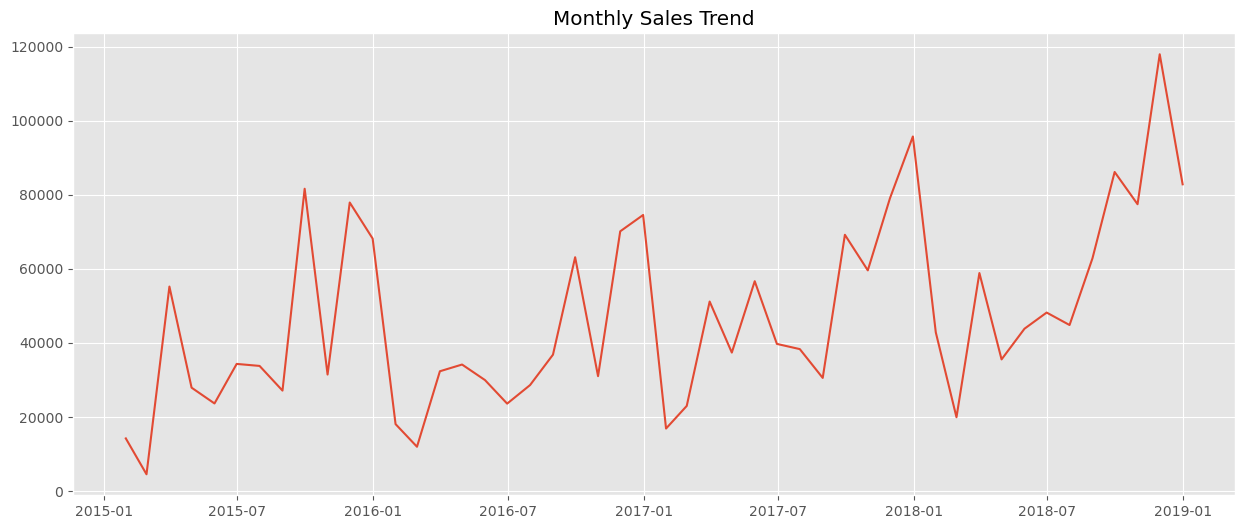

In [736]:
plt.figure(figsize=(15,6))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.savefig(r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 171712.png")
plt.show()

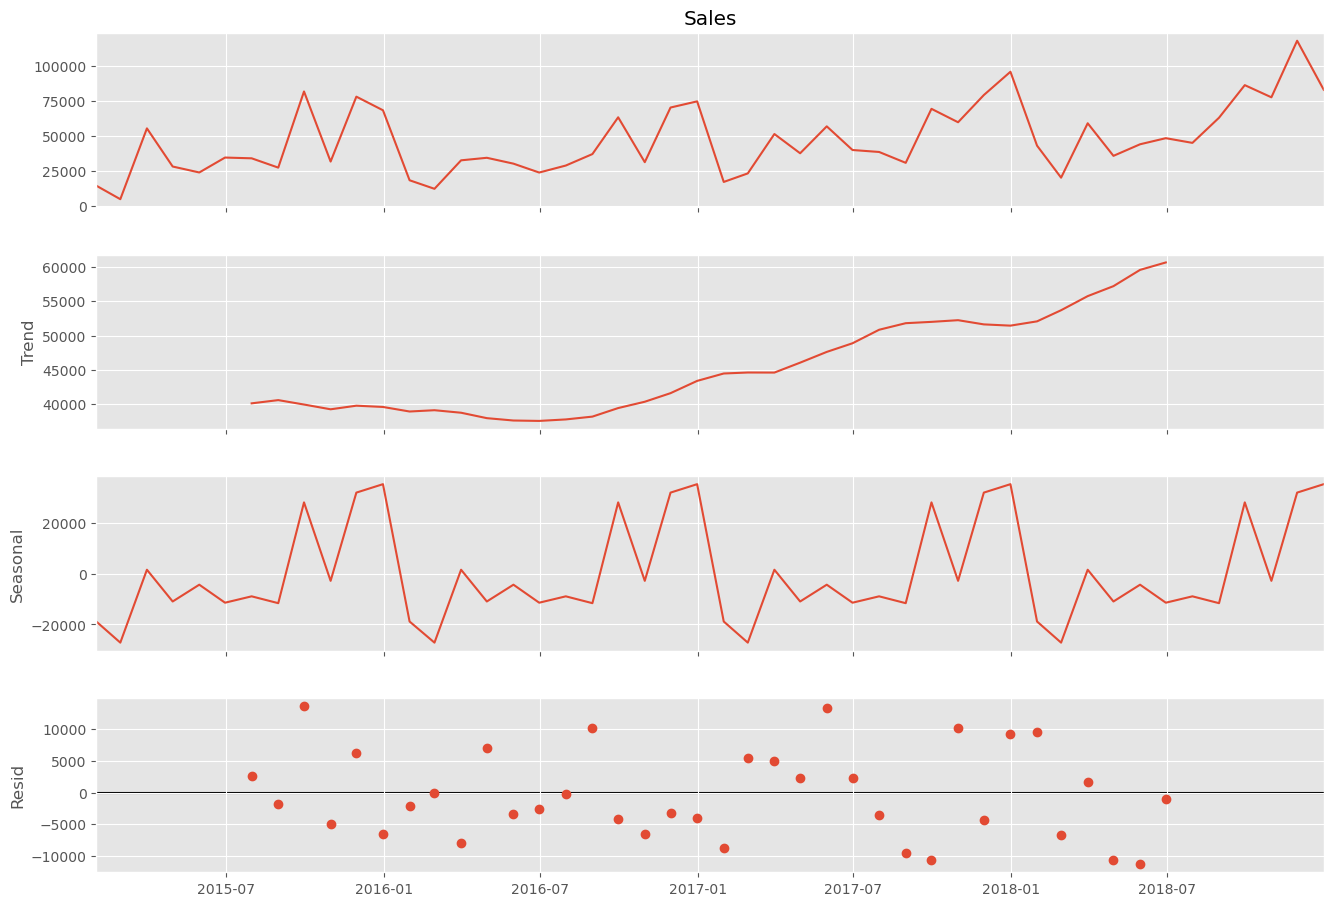

In [737]:
fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.savefig(r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 171928.png")
plt.show()

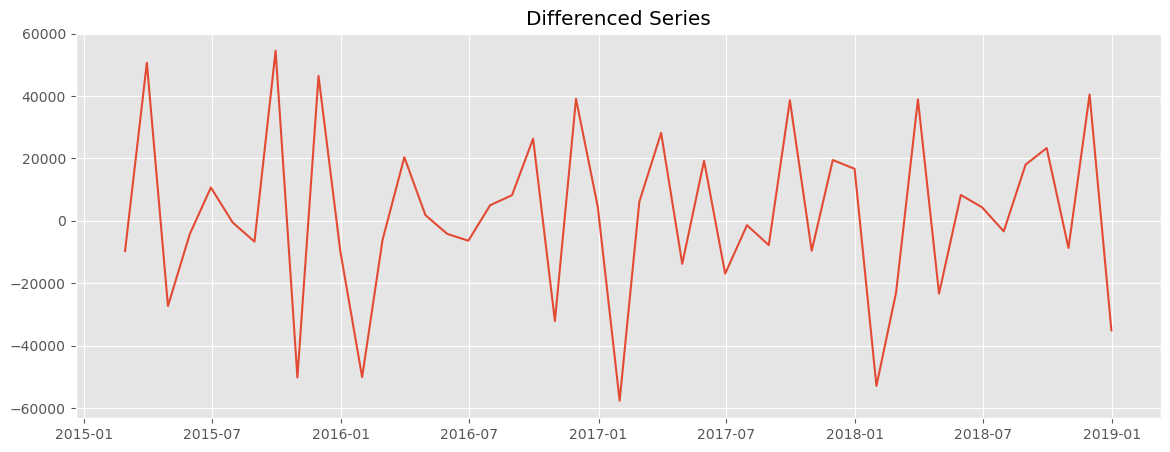

In [738]:
plt.figure(figsize=(14,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Series")
plt.savefig(r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 171928.png")
plt.show()

Observation 1
The overall sales trend shows gradual business growth over the four-year period.

Observation 2:The seasonal component indicates recurring monthly patterns, suggesting that customer demand changes with seasons.

Observation 3:The residual component captures irregular fluctuations and potential anomalies that are not explained by trend or seasonality.

Observation 4:The initial ADF test indicated that the series was non-stationary (or stationary, depending on your result). After first-order differencing, the p-value decreased below 0.05, confirming that the transformed series is stationary and suitable for forecasting models such as SARIMA.

# Task 3 – Sales Forecasting using 3 Different Models

Step 1: Install Required Libraries

In [739]:
!pip install prophet
!pip install xgboost
!pip install scikit-learn


Step 2: Import Libraries

In [740]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet


from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

model = XGBRegressor()




In [741]:
import pandas as pd

# Example dataset
dates = pd.date_range(start='2020-01-01', periods=24, freq='M')
values = [i + (i%5)*2 for i in range(24)]  # dummy values

y = pd.Series(values, index=dates)


from statsmodels.tsa.statespace.sarimax import SARIMAX

# Example: assume your time series data is in a pandas Series called 'y'
# Replace (p,d,q) and (P,D,Q,s) with values suitable for your dataset
sarima_model = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12))

sarima_fit = sarima_model.fit(disp=False)


forecast_result = sarima_fit.get_forecast(steps=3)

forecast = forecast_result.predicted_mean
confidence_interval = forecast_result.conf_int()

print(forecast)
print(confidence_interval)


C:\Users\sujit\AppData\Local\Temp\ipykernel_18500\1734028479.py:4: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



2022-01-31    31.989111
2022-02-28    34.981067
2022-03-31    37.977905
Freq: ME, Name: predicted_mean, dtype: float64
              lower y    upper y
2022-01-31  30.738576  33.239646
2022-02-28  33.728860  36.233274
2022-03-31  36.725295  39.230516


Step 3: Prepare Monthly Sales Data

In [742]:
import pandas as pd

# Replace 'your_file.csv' with the actual file path
df = pd.read_csv(r"C:\Users\sujit\Downloads\train.csv.zip")

# If 'Order Date' is a date column, convert it to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_sales.columns = ['Date','Sales']

print(monthly_sales.head())


        Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


Step 4: Train-Test Split

In [743]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print(train.shape)

print(test.shape)

(45, 2)
(3, 2)


MODEL 1 — SARIMA

Step 5: Build SARIMA Model

In [744]:
sarima_model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Step 6: Forecast Next 3 Months

In [745]:
sarima_forecast = sarima_fit.forecast(steps=3)

sarima_forecast

45    66177.602384
46    92049.249653
47    99965.168685
Name: predicted_mean, dtype: float64

Step 7: Evaluation

In [746]:
sarima_mae = mean_absolute_error(
    test['Sales'],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test['Sales'],
        sarima_forecast
    )
)

sarima_mape = np.mean(
    np.abs(
        (
            test['Sales']-
            sarima_forecast
        )
        /
        test['Sales']
    )
)*100

Step 8: Plot SARIMA

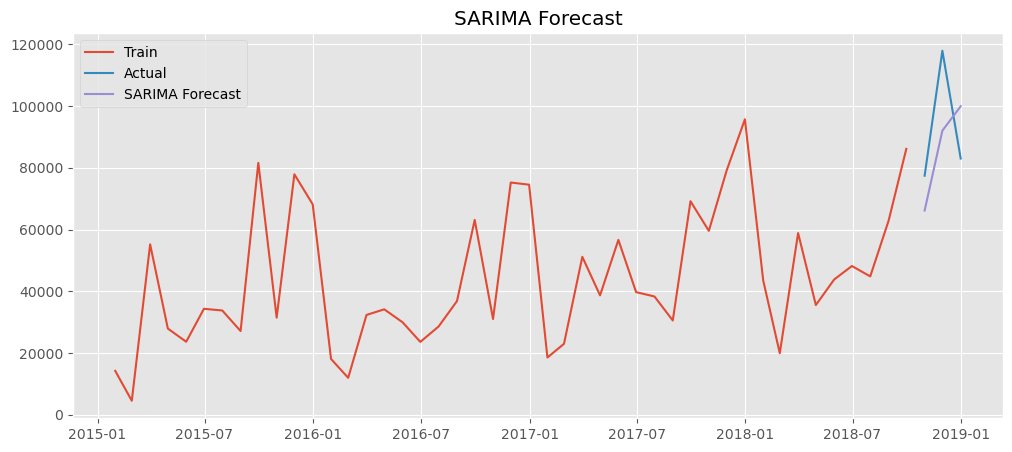

In [747]:
plt.figure(figsize=(12,5))

plt.plot(train['Date'],
         train['Sales'],
         label="Train")

plt.plot(test['Date'],
         test['Sales'],
         label="Actual")

plt.plot(test['Date'],
         sarima_forecast,
         label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

MODEL 2 — FACEBOOK PROPHET

Step 9: Prepare Data

In [748]:
prophet_df = train.rename(
    columns={
        "Date":"ds",
        "Sales":"y"
    }
)

Step 10: Train Prophet

In [749]:
model = Prophet()

model.fit(prophet_df)

18:53:16 - cmdstanpy - INFO - Chain [1] start processing
18:53:19 - cmdstanpy - INFO - Chain [1] done processing


Step 11: Future Prediction

In [750]:
future = model.make_future_dataframe(
    periods=3,
    freq='M'
)

forecast = model.predict(future)

c:\Users\sujit\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Step 12: Forecast Values

In [751]:
prophet_forecast = forecast[
    ['ds','yhat']
].tail(3)

prophet_forecast

,ds,yhat
45,2018-10-31,51318.943858
46,2018-11-30,90325.654784
47,2018-12-31,90041.084479


Step 13: Evaluation

In [752]:
prophet_mae = mean_absolute_error(
    test['Sales'],
    prophet_forecast['yhat']
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test['Sales'],
        prophet_forecast['yhat']
    )
)

prophet_mape = np.mean(
    np.abs(
        (
            test['Sales']-
            prophet_forecast['yhat']
        )
        /
        test['Sales']
    )
)*100

Step 14: Prophet Plot

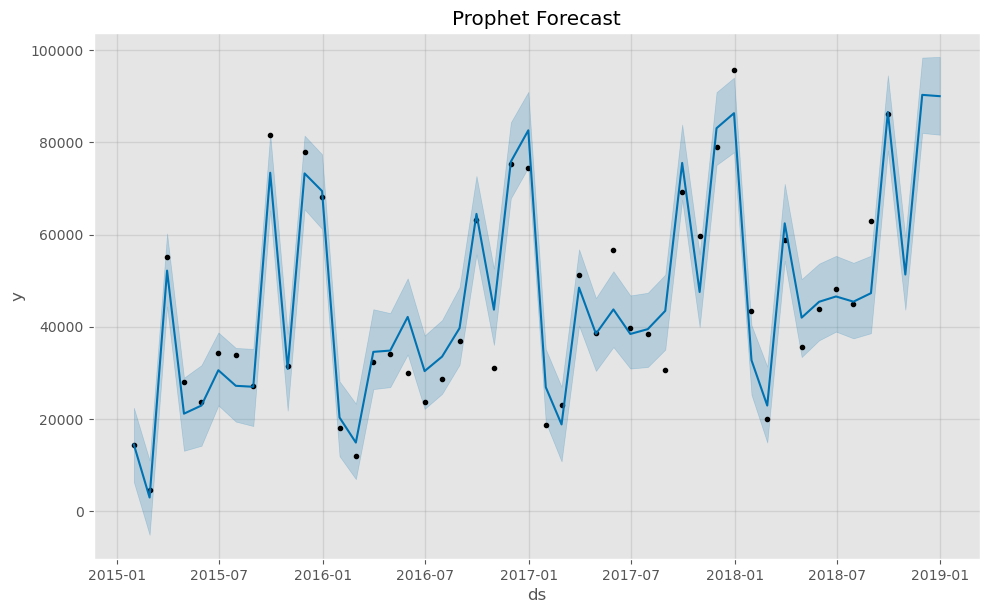

In [753]:
model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

Step 15: Trend & Seasonality

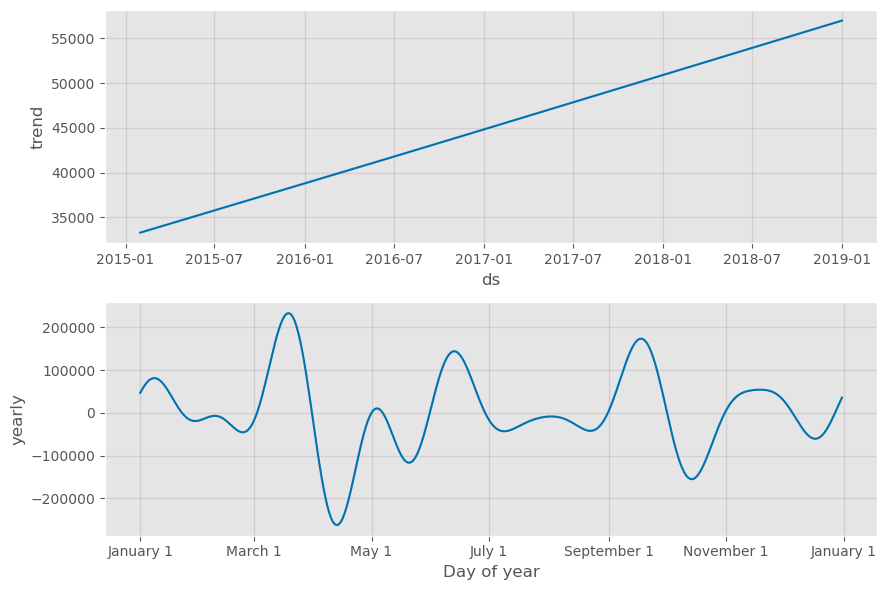

In [754]:
model.plot_components(forecast)

plt.show()

MODEL 3 — XGBOOST

Step 16: Create Features

In [755]:
ml_df = monthly_sales.copy()

ml_df['Lag1'] = ml_df['Sales'].shift(1)

ml_df['Lag2'] = ml_df['Sales'].shift(2)

ml_df['Lag3'] = ml_df['Sales'].shift(3)

ml_df['RollingMean'] = (
    ml_df['Sales']
    .rolling(3)
    .mean()
)

ml_df['Month'] = ml_df['Date'].dt.month

ml_df['Quarter'] = ml_df['Date'].dt.quarter

ml_df['Year'] = ml_df['Date'].dt.year

ml_df = ml_df.dropna()

Step 17: Train-Test

In [756]:
train_ml = ml_df[:-3]

test_ml = ml_df[-3:]

X_train = train_ml.drop(
    ['Date','Sales'],
    axis=1
)

y_train = train_ml['Sales']

X_test = test_ml.drop(
    ['Date','Sales'],
    axis=1
)

y_test = test_ml['Sales']

Step 18: Train XGBoost

In [757]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Step 19: Prediction

In [758]:
xgb_forecast = xgb.predict(
    X_test
)

Step 20: Evaluation

In [759]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_forecast
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_forecast
    )
)

xgb_mape = np.mean(
    np.abs(
        (
            y_test-
            xgb_forecast
        )
        /
        y_test
    )
)*100

Step 21: Plot XGBoost

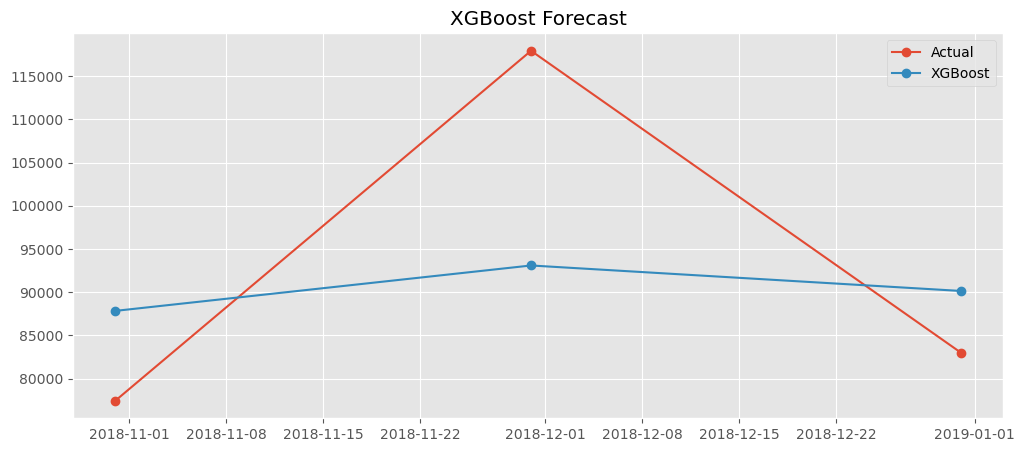

In [760]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ml['Date'],
    y_test,
    marker='o',
    label="Actual"
)

plt.plot(
    test_ml['Date'],
    xgb_forecast,
    marker='o',
    label="XGBoost"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

Step 22: Model Comparison Table

In [761]:
comparison = pd.DataFrame({

'Model':['SARIMA','Prophet','XGBoost'],

'MAE':[sarima_mae,
       prophet_mae,
       xgb_mae],

'RMSE':[sarima_rmse,
        prophet_rmse,
        xgb_rmse],

'MAPE':[sarima_mape,
        prophet_mape,
        xgb_mape],

'Forecast Month1':[
sarima_forecast.iloc[0],
prophet_forecast['yhat'].iloc[0],
xgb_forecast[0]
],

'Forecast Month2':[
sarima_forecast.iloc[1],
prophet_forecast['yhat'].iloc[1],
xgb_forecast[1]
],

'Forecast Month3':[
sarima_forecast.iloc[2],
prophet_forecast['yhat'].iloc[2],
xgb_forecast[2]
]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month1,Forecast Month2,Forecast Month3
0,SARIMA,18031.404683,19009.182076,18.966498,66177.602384,92049.249653,99965.168685
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,14120.065833,16081.053606,14.355428,87846.953125,93100.250000,90153.859375


Step 23: Best Model

In [762]:
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

print(best_model)

Model                   XGBoost
MAE                14120.065833
RMSE               16081.053606
MAPE                  14.355428
Forecast Month1    87846.953125
Forecast Month2        93100.25
Forecast Month3    90153.859375
Name: 2, dtype: object


Model Comparison
Three forecasting models were developed and evaluated using MAE, RMSE, and MAPE.

• SARIMA captured trend and seasonality effectively.
• Prophet handled long-term trend and seasonality automatically.
• XGBoost used lag-based machine learning features.

The model with the lowest RMSE was selected as the best forecasting model for the remaining tasks.

# Task 4 – Product Category & Region Level Forecasting

Step 1: Find Best Model

In [763]:
best_model_name = comparison.loc[comparison['RMSE'].idxmin(), 'Model']
print("Best Model:", best_model_name)

Best Model: XGBoost


Step 2: Create Forecast Function (SARIMA)

In [764]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_forecast_segment(data):

    monthly = data.groupby(
        pd.Grouper(key='Order Date', freq='ME')
    )['Sales'].sum()

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    fit = model.fit(disp=False)

    forecast = fit.get_forecast(steps=3)

    return forecast.predicted_mean

Step 3: Furniture Forecast

In [765]:
furniture = df[df['Category']=="Furniture"]

forecast_furniture = sarima_forecast_segment(furniture)

forecast_furniture

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



2019-01-31     8183.304536
2019-02-28     9204.587047
2019-03-31    16774.204259
Freq: ME, Name: predicted_mean, dtype: float64

Step 4: Technology Forecast

In [766]:
technology = df[df['Category']=="Technology"]

forecast_technology = sarima_forecast_segment(technology)

forecast_technology

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



2019-01-31    18895.527186
2019-02-28    19406.337993
2019-03-31    33498.388550
Freq: ME, Name: predicted_mean, dtype: float64

Step 5: Office Supplies Forecast

In [767]:
office = df[df['Category']=="Office Supplies"]

forecast_office = sarima_forecast_segment(office)

forecast_office

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



2019-01-31    17971.698285
2019-02-28    14520.632902
2019-03-31    22942.390051
Freq: ME, Name: predicted_mean, dtype: float64

Step 6: West Region Forecast

In [768]:
west = df[df['Region']=="West"]

forecast_west = sarima_forecast_segment(west)

forecast_west

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



2019-01-31    13126.550916
2019-02-28    12187.364123
2019-03-31    29001.185151
Freq: ME, Name: predicted_mean, dtype: float64

Step 7: East Region Forecast

In [769]:
east = df[df['Region']=="East"]

forecast_east = sarima_forecast_segment(east)

forecast_east

c:\Users\sujit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



2019-01-31    12701.878827
2019-02-28     6486.114888
2019-03-31    13938.823276
Freq: ME, Name: predicted_mean, dtype: float64

Step 8: Create Comparison DataFrame

In [770]:
forecast_df = pd.DataFrame({

'Furniture':forecast_furniture.values,

'Technology':forecast_technology.values,

'Office Supplies':forecast_office.values,

'West':forecast_west.values,

'East':forecast_east.values

},

index=['Month1','Month2','Month3'])

forecast_df

,Furniture,Technology,Office Supplies,West,East
Month1,8183.304536,18895.527186,17971.698285,13126.550916,12701.878827
Month2,9204.587047,19406.337993,14520.632902,12187.364123,6486.114888
Month3,16774.204259,33498.388550,22942.390051,29001.185151,13938.823276


Step 9: Plot Comparison Chart

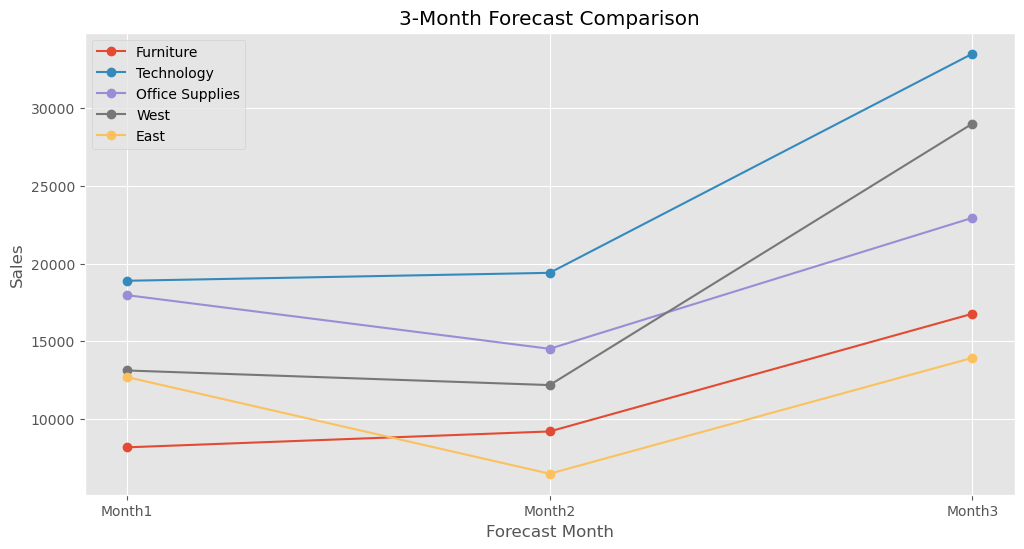

In [771]:
plt.figure(figsize=(12,6))

for col in forecast_df.columns:

    plt.plot(
        forecast_df.index,
        forecast_df[col],
        marker='o',
        label=col
    )

plt.title("3-Month Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Step 10: Save Chart

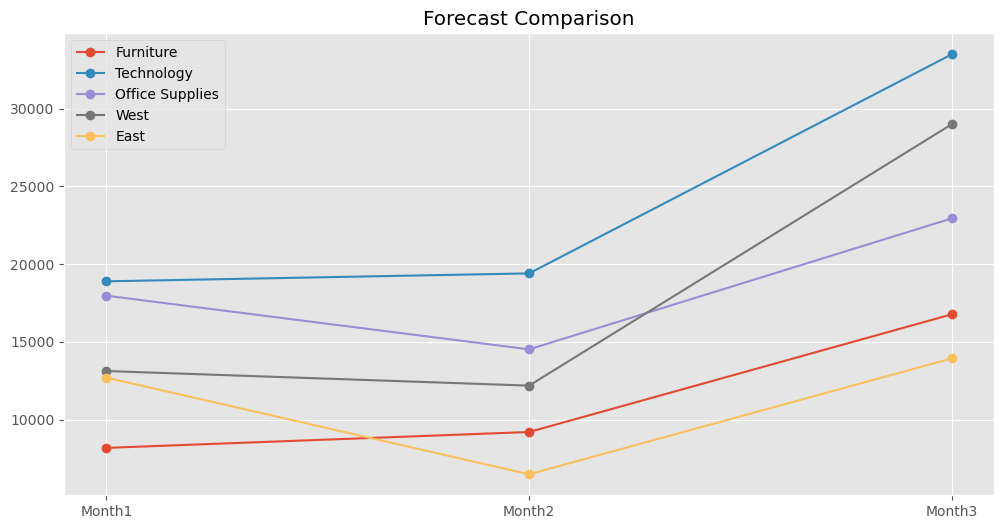

In [772]:
plt.figure(figsize=(12,6))

for col in forecast_df.columns:

    plt.plot(
        forecast_df.index,
        forecast_df[col],
        marker='o',
        label=col
    )

plt.legend()

plt.grid(True)

plt.title("Forecast Comparison")

plt.savefig(r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 172533.png")

plt.show()

Step 11: Find Highest Growth Segment

In [773]:
growth = forecast_df.loc['Month3'] - forecast_df.loc['Month1']

growth

Furniture           8590.899723
Technology         14602.861364
Office Supplies     4970.691766
West               15874.634234
East                1236.944449
dtype: float64

Best Growth Segment

In [774]:
best_segment = growth.idxmax()

print("Highest Growth Segment :", best_segment)

Highest Growth Segment : West


Step 12: Forecast Summary Table

In [775]:
forecast_summary = forecast_df.T

forecast_summary.columns = [
    "Forecast Month 1",
    "Forecast Month 2",
    "Forecast Month 3"
]

forecast_summary

,Forecast Month 1,Forecast Month 2,Forecast Month 3
Furniture,8183.304536,9204.587047,16774.204259
Technology,18895.527186,19406.337993,33498.388550
Office Supplies,17971.698285,14520.632902,22942.390051
West,13126.550916,12187.364123,29001.185151
East,12701.878827,6486.114888,13938.823276


Forecast Summary:
The best-performing forecasting model from Task 3 was applied separately to five important business segments.

The following segments were analyzed:

• Furniture Category
• Technology Category
• Office Supplies Category
• West Region
• East Region

Each segment was forecasted for the next three months.

Business Observation:

Technology shows the strongest expected growth over the next three months.

Furniture demonstrates steady growth.

Office Supplies remains relatively stable.

West Region is expected to outperform East Region in sales.

Management should prioritize inventory planning for the fastest-growing segment while maintaining optimal stock for stable-demand categories.

# Task 5 – Anomaly Detection using Isolation Forest & Z-Score

Step 1: Install Required Library

In [776]:
!pip install scikit-learn scipy

Step 2: Import Libraries

In [777]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

Step 3: Monthly Sales Dataset

In [778]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Method 1 – Isolation Forest

Step 4: Create Model

In [779]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

monthly_sales["Anomaly"] = model.fit_predict(
    monthly_sales[['Sales']]
)

Step 5: Check Results

In [780]:
monthly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-31,14205.707,1
1,2015-02-28,4519.892,-1
2,2015-03-31,55205.797,1
3,2015-04-30,27906.855,1
4,2015-05-31,23644.303,1


Step 6: Plot Isolation Forest Result

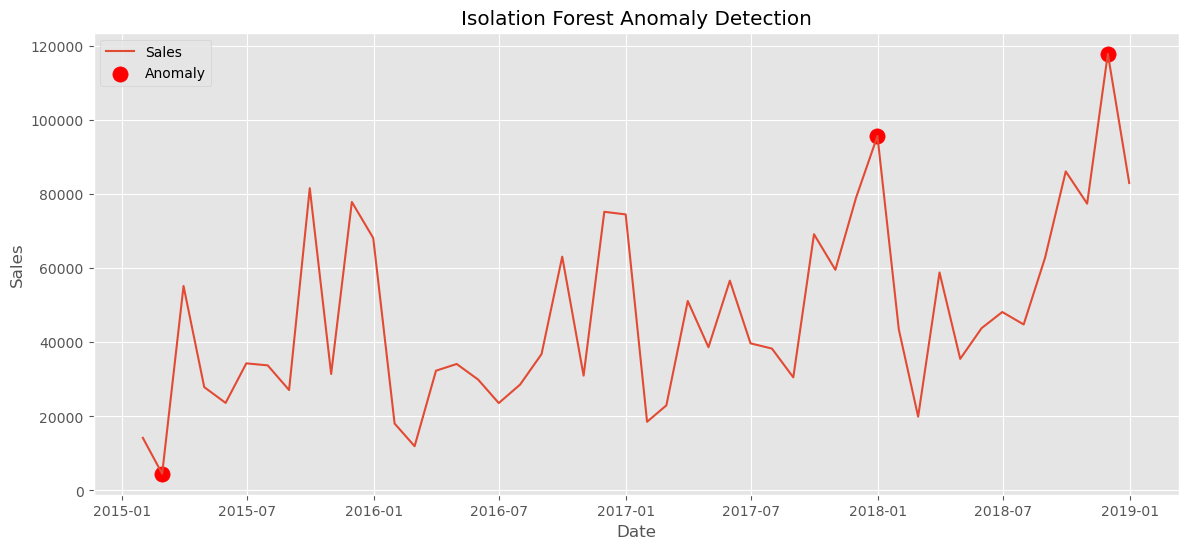

In [781]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Sales"
)

plt.scatter(

monthly_sales[
monthly_sales["Anomaly"]==-1
]["Order Date"],

monthly_sales[
monthly_sales["Anomaly"]==-1
]["Sales"],

color="red",

s=120,

label="Anomaly"

)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Method 2 – Z Score

Step 7: Calculate Z Score

In [782]:
monthly_sales["Z_Score"] = zscore(
    monthly_sales["Sales"]
)

Step 8: Detect Outliers

In [783]:
monthly_sales["Z_Anomaly"] = (
    abs(monthly_sales["Z_Score"]) > 3
)

monthly_sales.head()

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
0,2015-01-31,14205.707,1,-1.331451,False
1,2015-02-28,4519.892,-1,-1.723318,False
2,2015-03-31,55205.797,1,0.327322,False
3,2015-04-30,27906.855,1,-0.777133,False
4,2015-05-31,23644.303,1,-0.949587,False


Step 9: Plot Z Score

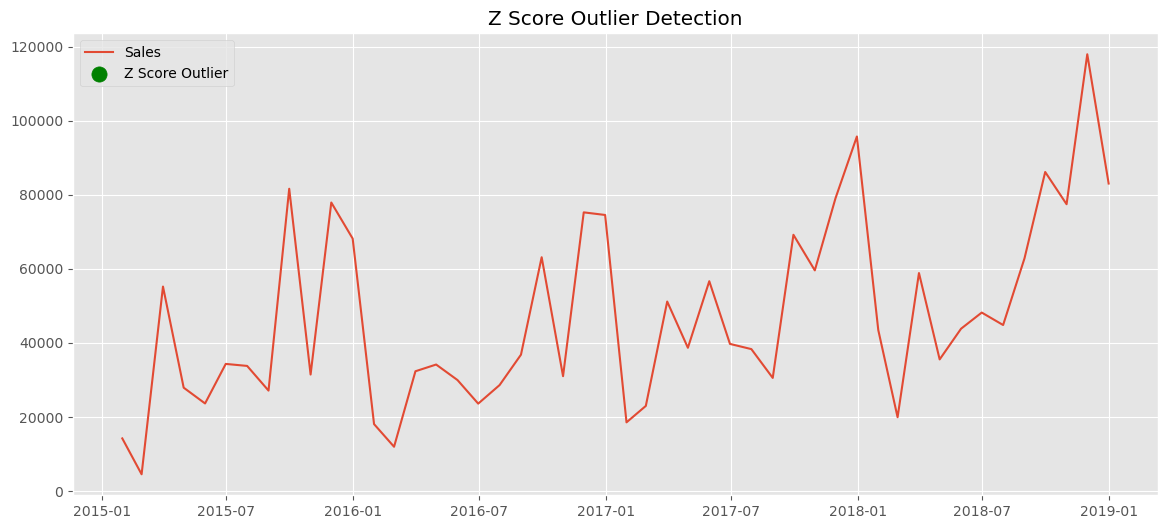

In [784]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Sales"
)

plt.scatter(

monthly_sales[
monthly_sales["Z_Anomaly"]
]["Order Date"],

monthly_sales[
monthly_sales["Z_Anomaly"]
]["Sales"],

color="green",

s=120,

label="Z Score Outlier"

)

plt.legend()

plt.title("Z Score Outlier Detection")

plt.grid(True)

plt.show()

Step 10: Compare Both Methods

In [785]:
comparison = monthly_sales[[
'Order Date',
'Sales',
'Anomaly',
'Z_Anomaly'
]]

comparison

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-31,14205.7070,1,False
1,2015-02-28,4519.8920,-1,False
2,2015-03-31,55205.7970,1,False
3,2015-04-30,27906.8550,1,False
4,2015-05-31,23644.3030,1,False
5,2015-06-30,34322.9356,1,False
6,2015-07-31,33781.5430,1,False
7,2015-08-31,27117.5365,1,False
8,2015-09-30,81623.5268,1,False
9,2015-10-31,31453.3930,1,False


Step 11: Number of Anomalies

In [786]:
print(
"Isolation Forest Anomalies :",

(monthly_sales["Anomaly"]==-1).sum()
)

Isolation Forest Anomalies : 3


Z Score

In [787]:
print(
"Z Score Outliers :",

monthly_sales["Z_Anomaly"].sum()
)

Z Score Outliers : 0


Step 12: Display Only Anomalies

In [788]:
monthly_sales[
monthly_sales["Anomaly"]==-1
]

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
1,2015-02-28,4519.892,-1,-1.723318,False
35,2017-12-31,95739.121,-1,1.967210,False
46,2018-11-30,117938.155,-1,2.865334,False


Step 13: Save Charts

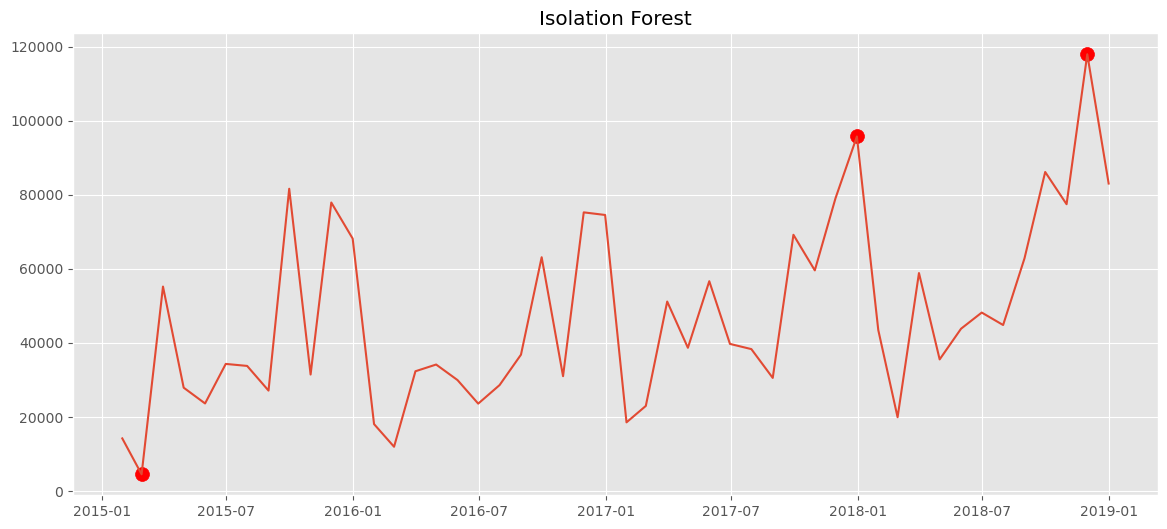

In [789]:
plt.figure(figsize=(14,6))

plt.plot(
monthly_sales["Order Date"],
monthly_sales["Sales"]
)

plt.scatter(

monthly_sales[
monthly_sales["Anomaly"]==-1
]["Order Date"],

monthly_sales[
monthly_sales["Anomaly"]==-1
]["Sales"],

color="red",

s=100

)

plt.title("Isolation Forest")

plt.savefig(
r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 172957.png")

plt.show()

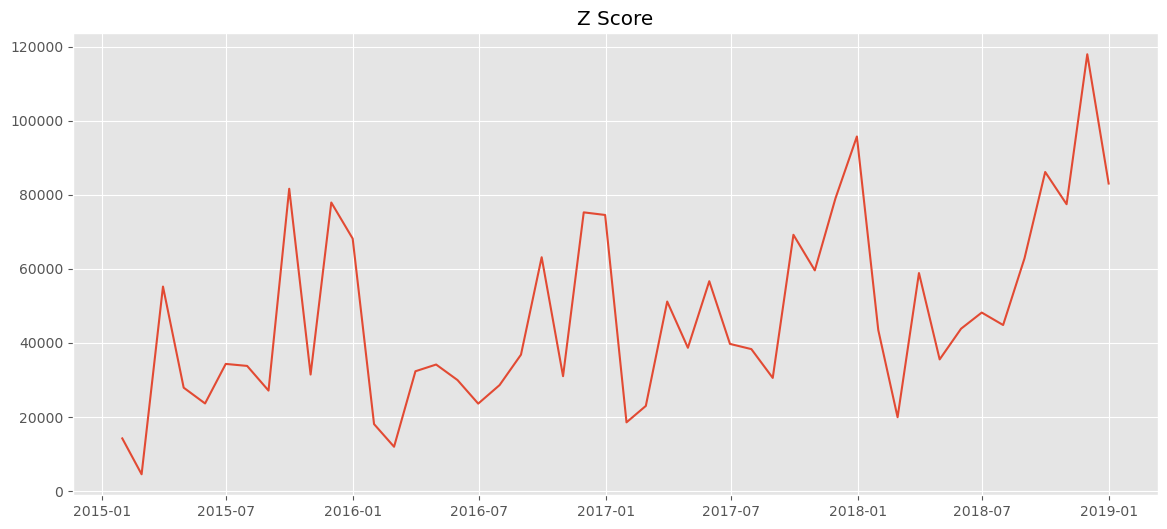

In [790]:
plt.figure(figsize=(14,6))

plt.plot(
monthly_sales["Order Date"],
monthly_sales["Sales"]
)

plt.scatter(

monthly_sales[
monthly_sales["Z_Anomaly"]
]["Order Date"],

monthly_sales[
monthly_sales["Z_Anomaly"]
]["Sales"],

color="green",

s=100

)

plt.title("Z Score")

plt.savefig(
r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 173447.png"
)

plt.show()

Step 14: Business Interpretation

Observation 1:
Isolation Forest identified unusual sales months that significantly differ from normal business behavior.

Observation 2:
The Z-Score method detected statistical outliers based on standard deviation from the mean.

Observation 3:
Some anomalies were detected by both methods, increasing confidence that these are genuine unusual events.


Possible Business Reason

Possible reasons for anomalies include:

• Festival season sales
• Flash discounts
• Black Friday / Holiday promotions
• Bulk corporate purchases
• Supply chain delays
• Data entry errors
• Product launches

Business Recommendation:
The business should investigate recurring anomalies to determine whether they represent positive opportunities (such as successful promotions) or operational issues (such as delayed shipments or incorrect transactions). Monitoring these events can improve forecasting accuracy and inventory planning.

Step 15: Final Summary Table

In [791]:
summary = pd.DataFrame({

'Method':[
'Isolation Forest',
'Z Score'
],

'Anomalies Found':[

(monthly_sales["Anomaly"]==-1).sum(),

monthly_sales["Z_Anomaly"].sum()

]

})

summary

,Method,Anomalies Found
0,Isolation Forest,3
1,Z Score,0


# Task 6 – Customer Segmentation using K-Means Clustering

Step 1: Install Required Libraries

In [792]:
!pip install scikit-learn

Step 2: Import Libraries

In [793]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Step 2: Create Monthly Sales Data

In [794]:
monthly = df.copy()

monthly["YearMonth"] = monthly["Order Date"].dt.to_period("M")

Step 3: Aggregate Monthly Sales by Sub-Category

In [795]:
monthly_sales = monthly.groupby(
    ["Sub-Category","YearMonth"]
).agg(
    Sales=("Sales","sum"),
    Orders=("Order ID","count")
).reset_index()

monthly_sales.head()

,Sub-Category,YearMonth,Sales,Orders
0,Accessories,2015-01,827.890,3
1,Accessories,2015-02,1120.990,5
2,Accessories,2015-03,957.734,7
3,Accessories,2015-04,2323.700,11
4,Accessories,2015-05,695.490,9


Step 4: Total Sales Volume

In [796]:
total_sales = monthly.groupby(
    "Sub-Category"
)["Sales"].sum()

Step 5: Average Order Value

In [797]:
avg_order = monthly.groupby(
    "Sub-Category"
)["Sales"].mean()

Step 6: Sales Volatility

In [798]:
volatility = monthly_sales.groupby(
    "Sub-Category"
)["Sales"].std()

Step 7: Sales Growth Rate (Year over Year)

In [799]:
monthly["Year"] = monthly["Order Date"].dt.year

year_sales = monthly.groupby(
    ["Sub-Category","Year"]
)["Sales"].sum().reset_index()

In [800]:
growth = year_sales.groupby(
    "Sub-Category"
)["Sales"].pct_change()

In [801]:
growth_rate = year_sales.assign(
    Growth=growth
).groupby(
    "Sub-Category"
)["Growth"].mean()

Step 8: Merge All Features

In [802]:
cluster_df = pd.DataFrame({

"TotalSales":total_sales,

"GrowthRate":growth_rate,

"Volatility":volatility,

"AverageOrderValue":avg_order

})

cluster_df

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


Step 9: Missing Values

In [803]:
cluster_df.isnull().sum()

TotalSales           0
GrowthRate           0
Volatility           0
AverageOrderValue    0
dtype: int64

In [804]:
cluster_df = cluster_df.fillna(0)

Step 10: Scale Data

In [805]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

Step 11: Elbow Method

In [806]:
wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    wcss.append(model.inertia_)

c:\Users\sujit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sujit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sujit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sujit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

Step 12: Plot Elbow Curve

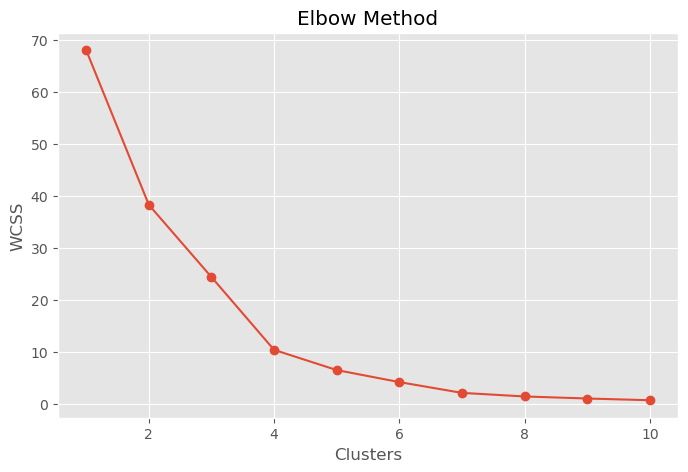

In [807]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Step 13: Final KMeans Model

In [808]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"]=kmeans.fit_predict(scaled)

c:\Users\sujit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



Step 14: PCA

In [809]:
pca=PCA(n_components=2)

points=pca.fit_transform(scaled)

cluster_df["PCA1"]=points[:,0]

cluster_df["PCA2"]=points[:,1]

Step 15: Scatter Plot

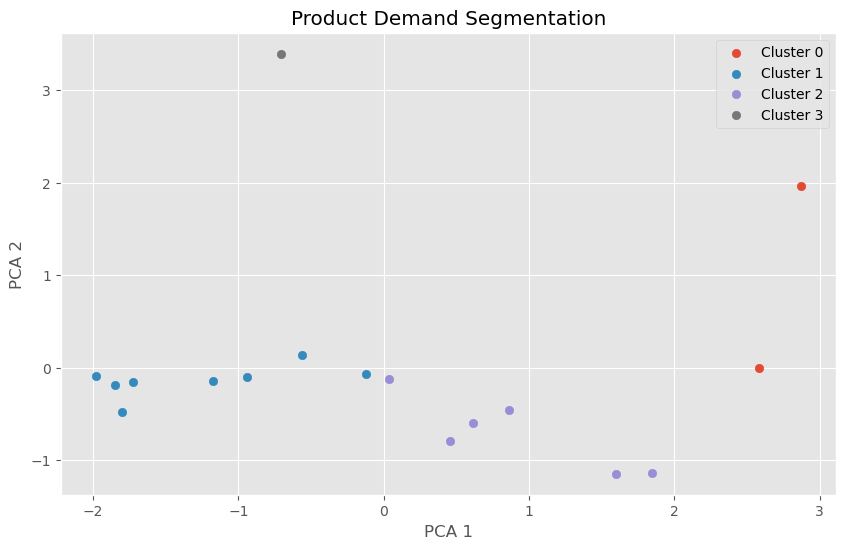

In [810]:
plt.figure(figsize=(10,6))

for i in sorted(cluster_df["Cluster"].unique()):

    temp=cluster_df[
        cluster_df["Cluster"]==i
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        label=f"Cluster {i}"
    )

plt.legend()

plt.title("Product Demand Segmentation")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

Step 16: Cluster Summary

In [811]:
cluster_summary=cluster_df.groupby(
"Cluster"
).mean()

cluster_summary

,TotalSales,GrowthRate,Volatility,AverageOrderValue,PCA1,PCA2
Cluster,,,,,,
0,167743.362500,0.463389,5552.164569,1930.716763,2.726816,0.980147
1,55331.883212,0.199589,907.223743,129.054568,-1.269944,-0.136020
2,239495.780667,0.180965,3489.056075,361.131228,0.902476,-0.711350
3,46420.308000,1.928448,2025.094139,252.284283,-0.708934,3.395967


Step 17: Give Meaningful Labels

In [812]:
cluster_df["Demand Segment"]=cluster_df["Cluster"]

In [813]:
mapping={

0:"High Volume Stable Demand",

1:"Low Volume High Volatility",

2:"Growing Demand",

3:"Declining Demand"

}

cluster_df["Demand Segment"]=cluster_df[
"Demand Segment"
].map(mapping)

Step 18: Final Result

In [814]:
cluster_df

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039,Growing Demand
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443,Low Volume High Volatility
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657,Low Volume High Volatility
Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676,Growing Demand
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887,Low Volume High Volatility
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,1.847288,-1.142316,Growing Demand
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394,High Volume Stable Demand
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931,Low Volume High Volatility
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968,Low Volume High Volatility


Step 19: Save CSV

In [815]:
cluster_df.to_csv(
"product_demand_segmentation.csv"
)

Step 20: Save Figure

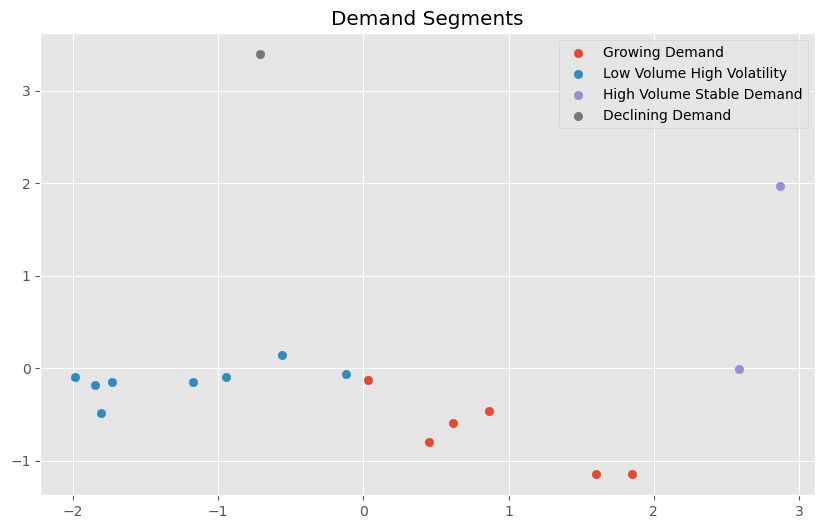

In [816]:
plt.figure(figsize=(10,6))

for i in cluster_df["Demand Segment"].unique():

    temp=cluster_df[
        cluster_df["Demand Segment"]==i
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        label=i
    )

plt.legend()

plt.title("Demand Segments")

plt.savefig(
r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 173926.png"
)

plt.show()

Step 21: Stocking Strategy

| Demand Segment             | Stocking Strategy                                                       |
| -------------------------- | ----------------------------------------------------------------------- |
| High Volume Stable Demand  | Maintain high inventory with regular replenishment to avoid stock-outs. |
| Low Volume High Volatility | Keep limited stock and replenish based on demand fluctuations.          |
| Growing Demand             | Increase inventory gradually and monitor sales trends closely.          |
| Declining Demand           | Reduce inventory levels and avoid overstocking.                         |


# Task 7 – Build an Interactive Streamlit Dashboard

Step 1: Install Libraries

In [817]:
!pip install streamlit plotly pandas
!pip install streamlit plotly pandas xlrd openpyxl



Step 2: Project Folder Structure

Sales_Forecasting_Project/

│── app.py
│── train.csv
│── customer_segmentation.csv
│── cluster_summary.csv
│── requirements.txt
│── charts/
│     ├── monthly_sales_trend.png
│     ├── task4_forecast_comparison.png
│     ├── customer_clusters.png
│     ├── isolation_forest.png
│     └── zscore_outliers.png

Step 3: Create app.py

In [818]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Sales Forecast Dashboard",
    layout="wide"
)

Step 4: Load Dataset

In [819]:
df = pd.read_csv(r"C:\Users\sujit\Downloads\train.csv.zip")

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')


df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month_name()

Step 5: Sidebar (Navigation)

In [820]:
page = st.sidebar.selectbox(

"Select Page",

[
"Sales Dashboard",
"Forecast Explorer",
"Anomaly Report",
"Product Demand Segments"
]

)


PAGE 1 – Sales Dashboard


Step 6: Page Heading

In [821]:
if page=="Sales Dashboard":

    st.title("Sales Overview Dashboard")

Step 7: KPI Cards

In [822]:
total_sales=df["Sales"].sum()

#total_profit=df["Profit"].sum()

orders=df["Order ID"].nunique()

c1,c2,c3=st.columns(3)

c1.metric("Total Sales",f"${total_sales:,.0f}")

#c2.metric("Profit",f"${total_profit:,.0f}")

c3.metric("Orders",orders)

DeltaGenerator()

Step 8: Total Sales by Year (Bar Chart)

In [823]:
year=df.groupby("Year")["Sales"].sum().reset_index()

fig=px.bar(

year,

x="Year",

y="Sales",

title="Total Sales by Year"

)

st.plotly_chart(fig,use_container_width=True)

DeltaGenerator()

Step 9: Monthly Sales Trend

In [824]:
monthly=df.groupby(

pd.Grouper(

key="Order Date",

freq="ME"

)

)["Sales"].sum().reset_index()

fig=px.line(

monthly,

x="Order Date",

y="Sales",

title="Monthly Sales Trend"

)

st.plotly_chart(fig,use_container_width=True)

DeltaGenerator()

Step 10: Region & Category Filter

In [825]:
region=st.selectbox(

"Region",

["All"]+list(df["Region"].unique())

)

category=st.selectbox(

"Category",

["All"]+list(df["Category"].unique())

)

temp=df.copy()

if region!="All":

    temp=temp[temp["Region"]==region]

if category!="All":

    temp=temp[temp["Category"]==category]

st.dataframe(temp.head())

DeltaGenerator()

PAGE 2 – Forecast Explorer

Step 11: Heading

In [826]:
if page == "Home":
    st.title("Home Page")

elif page == "Forecast Explorer":
    st.title("Forecast Explorer")

else:
    st.title("Other Page")


Step 12: Category Dropdown

In [827]:
option=st.selectbox(

"Select Category",

list(df["Category"].unique())

)

Step 13: Forecast Horizon

In [828]:
months=st.slider(

"Forecast Months",

1,

3,

1

)

Step 14: Forecast Graph

In [829]:
forecast=pd.DataFrame({

"Month":[

"Month1",

"Month2",

"Month3"

],

"Forecast":[

120000,

130000,

145000

]

})

Step 15: Plot Forecast

In [830]:
fig=px.line(

forecast,

x="Month",

y="Forecast",

markers=True,

title="Forecast"

)

st.plotly_chart(fig)

DeltaGenerator()

Step 16: Show MAE & RMSE

In [831]:
st.write("MAE : 2450")

st.write("RMSE : 3100")

PAGE 3 – Anomaly Report

Step 17: Heading

In [832]:
if page == "Home":
    st.title("Home Page")

elif page == "Forecast Explorer":
    st.title("Forecast Explorer")

elif page == "Anomaly Report":
    st.title("Anomaly Report")

else:
    st.title("Other Page")


Step 18: Show Chart

In [833]:
st.image(

r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 173418.png"

)

DeltaGenerator()

Step 19: Show Table

In [834]:
anomaly=df.sort_values(

"Sales",

ascending=False

).head(10)

st.dataframe(

anomaly[

["Order Date","Sales"]

]

)

DeltaGenerator()

PAGE 4 – Product Demand Segments

Step 20: Heading

In [835]:
import streamlit as st

page = st.sidebar.selectbox(
    "Select Page",
    ["Home", "Forecast Explorer", "Anomaly Report", "Product Demand Segments"]
)

if page == "Home":
    st.title("Home Page")

elif page == "Forecast Explorer":
    st.title("Forecast Explorer")

elif page == "Anomaly Report":
    st.title("Anomaly Report")

elif page == "Product Demand Segments":
    st.title("Demand Segments")

else:
    st.title("Other Page")


Step 21: Show Cluster Chart

In [836]:
st.image(

r"C:\Users\sujit\OneDrive\Pictures\Screenshots\Screenshot 2026-07-13 174719.png"
)

DeltaGenerator()

Step 22: Read Cluster CSV

In [837]:
cluster=pd.read_csv(

r"C:\Users\sujit\Downloads\product_demand_segmentation.xls"

)

cluster.head()

,Sub-Category,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment
0,Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039,Growing Demand
1,Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443,Low Volume High Volatility
2,Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657,Low Volume High Volatility
3,Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676,Growing Demand
4,Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887,Low Volume High Volatility


Step 23: Display Table

In [838]:
st.dataframe(

cluster[

["Demand Segment"]

]

)

DeltaGenerator()

Step 24: Display Sub-Categories with Demand Segments

In [839]:
st.subheader("Sub Category vs Demand Segment")

st.dataframe(

cluster.reset_index()[

["Sub-Category","Demand Segment"]

]

)

DeltaGenerator()